In [1]:
import pandas as pd

from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df= pd.read_csv("income.csv")
df.head()

,NAME,AGE,INCOME($)
0,Rob,27,50000
1,Michael,29,60000
2,Ismail,29,55000
3,Kory,28,65000
4,Gautam,42,150000


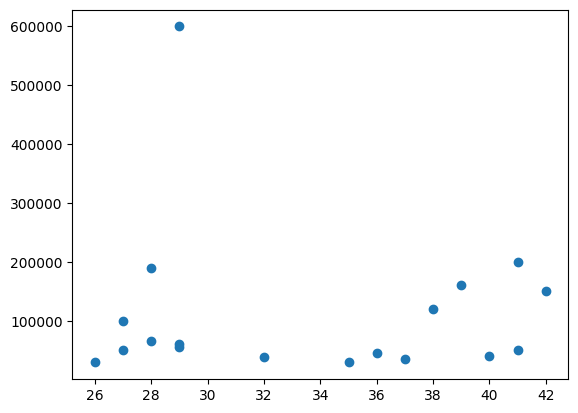

In [3]:
plt.scatter(df['AGE'],df['INCOME($)'])

In [14]:
from sklearn.cluster import KMeans


In [15]:
k= KMeans(n_clusters=3)
k

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [16]:
y_predicted= k.fit_predict(df[['AGE','INCOME($)']])
y_predicted

array([1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 2, 1, 1, 1], dtype=int32)

In [17]:
df['cluster']= y_predicted
df.head()

,NAME,AGE,INCOME($),cluster
0,Rob,27,50000,1
1,Michael,29,60000,1
2,Ismail,29,55000,1
3,Kory,28,65000,1
4,Gautam,42,150000,0


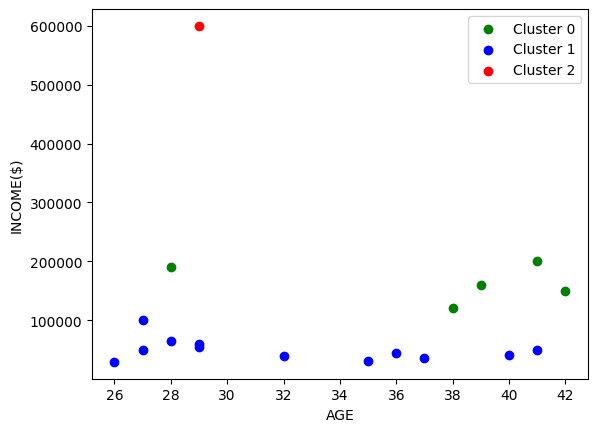

In [22]:
#dividing these into 3 separate data frames
df1= df[df.cluster==0]
df2= df[df.cluster==1]
df3= df[df.cluster==2]
plt.scatter(df1.AGE,df1['INCOME($)'],color='green',label='Cluster 0')
plt.scatter(df2.AGE,df2['INCOME($)'],color='blue',label='Cluster 1')
plt.scatter(df3.AGE,df3['INCOME($)'],color='red',label='Cluster 2')

plt.xlabel('AGE')
plt.ylabel('INCOME($)')
plt.legend()




In [50]:
#to improve the scaling for good clustering 
#we need to preprocess with minmaxscaler 

from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler()

# Fit and transform must use a 2D structure
#df[['INCOME($)']] = scaler.fit_transform(df[['INCOME($)']])

df[['INCOME($)','AGE']] = scaler.fit_transform(df[['INCOME($)','AGE']])
df

,NAME,AGE,INCOME($)
0,Rob,0.0625,0.036778
1,Michael,0.1875,0.054291
2,Ismail,0.1875,0.045534
3,Kory,0.1250,0.063047
4,Gautam,1.0000,0.211909
5,Andrea,0.8125,0.229422
6,Donald,0.9375,0.299475
7,Tom,0.7500,0.159370
8,Arnold,0.6250,0.028021
9,Jared,0.5625,0.001751


In [52]:
k=KMeans(n_clusters=3)
y_predicted= k.fit_predict(df[['AGE','INCOME($)']])
y_predicted

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 1, 0, 0], dtype=int32)

In [53]:
df['cluster']=y_predicted
df

,NAME,AGE,INCOME($),cluster
0,Rob,0.0625,0.036778,1
1,Michael,0.1875,0.054291,1
2,Ismail,0.1875,0.045534,1
3,Kory,0.1250,0.063047,1
4,Gautam,1.0000,0.211909,0
5,Andrea,0.8125,0.229422,0
6,Donald,0.9375,0.299475,0
7,Tom,0.7500,0.159370,0
8,Arnold,0.6250,0.028021,0
9,Jared,0.5625,0.001751,0


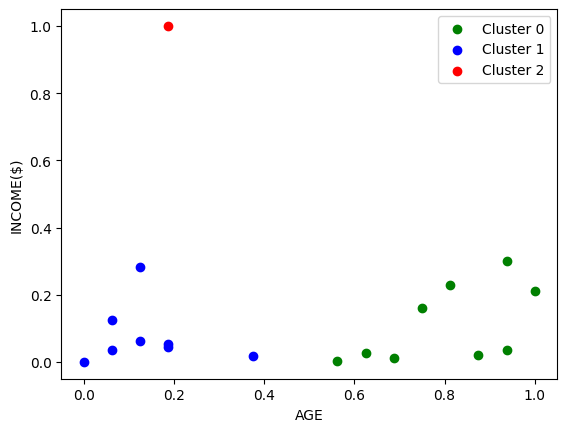

In [54]:
df1= df[df.cluster==0]
df2= df[df.cluster==1]
df3= df[df.cluster==2]
plt.scatter(df1.AGE,df1['INCOME($)'],color='green',label='Cluster 0')
plt.scatter(df2.AGE,df2['INCOME($)'],color='blue',label='Cluster 1')
plt.scatter(df3.AGE,df3['INCOME($)'],color='red',label='Cluster 2')

plt.xlabel('AGE')
plt.ylabel('INCOME($)')
plt.legend()
#now u can can see better clusters than before

In [55]:
k.cluster_centers_

array([[0.79861111, 0.11072193],
       [0.140625  , 0.07793345],
       [0.1875    , 1.        ]])

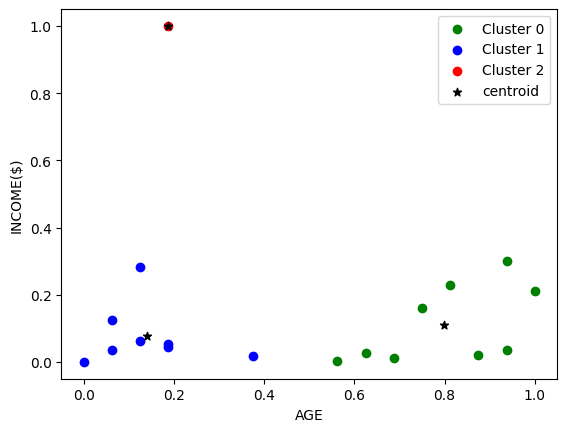

In [60]:
df1= df[df.cluster==0]
df2= df[df.cluster==1]
df3= df[df.cluster==2]
plt.scatter(df1.AGE,df1['INCOME($)'],color='green',label='Cluster 0')
plt.scatter(df2.AGE,df2['INCOME($)'],color='blue',label='Cluster 1')
plt.scatter(df3.AGE,df3['INCOME($)'],color='red',label='Cluster 2')
plt.scatter(k.cluster_centers_[:,0],k.cluster_centers_[:,1],marker='*',color='black',label='centroid')
#here [:,0] means select all rows(:) with first column(0)
plt.xlabel('AGE')

plt.ylabel('INCOME($)')
plt.legend()

In [61]:
#elbow methoddddddddddddddd
k_range= range(1,10)
sse= []
for k in k_range:
    k= KMeans(n_clusters=k)
    k.fit(df[['AGE','INCOME($)']])
    sse.append(k.inertia_) # inertia_ method computes the error
sse
    

[3.1365678058681437,
 1.1971946577356154,
 0.43950222387568677,
 0.27969604774112,
 0.21554975583656147,
 0.1676070998995014,
 0.12144389591221072,
 0.07827625629969343,
 0.03399282709395955]

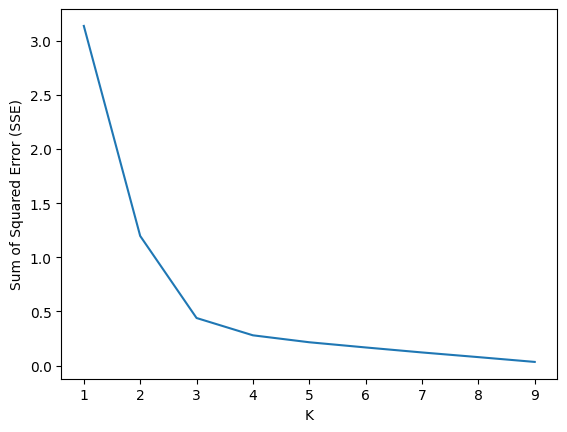

In [62]:
plt.xlabel('K')
plt.ylabel('Sum of Squared Error (SSE)')
plt.plot(k_range,sse)
#k=3 is the elbow from the graph